# PSI-мониторинг train/test drift

В этом ноутбуке рассчитывается `Population Stability Index` (`PSI`) для сравнения распределений признаков между train и test выборками.

Цель блока — показать, как можно контролировать стабильность распределения входных данных. В реальном production-сценарии такой же подход можно использовать для мониторинга дрейфа новых данных относительно обучающей выборки.

## 1. Импорты и базовые настройки

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
TEST_SIZE = 0.2

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 2. Пути к данным и артефактам

Ноутбук рассчитан на запуск из папки `notebooks` или из корня проекта.

In [2]:
# Определяем корень проекта.
# Если ноутбук запускается из папки notebooks, поднимаемся на уровень выше.
# Если запускается из корня проекта, используем текущую папку.

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "medical_cost_prediction_dataset.csv"

IMAGES_DIR = PROJECT_ROOT / "assets" / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

DRIFT_PLOT_PATH = IMAGES_DIR / "psi_train_test_report.png"

## 3. Загрузка и подготовка данных

Используем тот же синтетический датасет и тот же набор признаков, что и в основном ML-исследовании.

Целевая переменная `annual_medical_cost` корректируется до полной стоимости медицинских расходов до страхового покрытия. Затем `insurance_type` и `insurance_coverage_pct` исключаются, так как не используются в ML-моделировании.

In [3]:
df = pd.read_csv(DATA_PATH)

df["insurance_coverage_pct"] = df["insurance_coverage_pct"].astype(float)
df["annual_medical_cost"] = round(df["annual_medical_cost"] / (1 - df["insurance_coverage_pct"] / 100))

df = df.drop(columns=["insurance_type", "insurance_coverage_pct"], axis=1)

# Приводим бинарные признаки к тому же виду, что использовался в ML-исследовании
df["smoker"] = df["smoker"].map({"Yes": 1, "No": 0}).astype("int64")
df["gender"] = df["gender"].map({"Male": 1, "Female": 0}).astype("int64")

df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,city_type,previous_year_cost,annual_medical_cost
0,69,1,29.4,0,1,0,0,0,Medium,14825,4.4,8,1,0,4,Semi-Urban,10885,13228.0
1,32,0,22.9,0,1,0,0,0,Medium,3620,6.0,7,4,3,0,Semi-Urban,18722,30444.0
2,89,1,25.7,0,0,0,0,0,High,10578,4.5,7,2,0,3,Urban,4196,8410.0
3,78,1,31.9,1,0,1,0,0,Low,6226,8.6,9,6,1,7,Urban,11128,26655.0
4,38,1,27.7,0,0,0,0,0,High,6253,5.7,3,6,0,6,Urban,15110,13924.0


## 4. Признаки, использованные в ML-моделировании

In [4]:
target_col = "annual_medical_cost"

numeric_features = [
    "age",
    "bmi",
    "daily_steps",
    "sleep_hours",
    "doctor_visits_per_year",
    "hospital_admissions",
    "medication_count",
    "previous_year_cost",
    "stress_level"
]

binary_features = [
    "gender",
    "smoker",
    "diabetes",
    "hypertension",
    "heart_disease",
    "asthma"
]

categorical_features = [
    "physical_activity_level",
    "city_type"
]

feature_cols = numeric_features + binary_features + categorical_features

required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

assert len(missing_cols) == 0, f"В df отсутствуют колонки: {missing_cols}"
assert df[target_col].isna().sum() == 0, "В целевой переменной есть пропуски"

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5000, 17)
y shape: (5000,)


## 5. Train/test split

Делаем такой же фиксированный train/test split, как в ML-исследовании: 80/20 со стратификацией по бинам целевой переменной.

In [5]:
target_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Train shape: (4000, 17)
Test shape:  (1000, 17)


## 6. PSI-функции

`PSI` сравнивает распределения признака в двух выборках. В этом ноутбуке train используется как `expected`, а test — как `actual`.

Ориентировочная интерпретация:

```text
PSI < 0.1      — низкий дрейф
0.1–0.2        — умеренный дрейф
PSI >= 0.2     — высокий дрейф
```

In [6]:
def psi_from_proportions(expected_pct, actual_pct, eps=1e-6):
    expected_pct = np.clip(expected_pct, eps, None)
    actual_pct = np.clip(actual_pct, eps, None)

    return float(
        np.sum(
            (actual_pct - expected_pct)
            * np.log(actual_pct / expected_pct)
        )
    )


def numerical_psi(expected, actual, bins=10, eps=1e-6):
    expected = pd.to_numeric(expected, errors="coerce").dropna()
    actual = pd.to_numeric(actual, errors="coerce").dropna()

    if expected.nunique() <= 1 or actual.empty:
        return 0.0

    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(
        np.quantile(expected, quantiles)
    )

    if len(breakpoints) < 3:
        return 0.0

    expected_counts, _ = np.histogram(
        expected,
        bins=breakpoints
    )
    actual_counts, _ = np.histogram(
        actual,
        bins=breakpoints
    )

    expected_pct = np.clip(
        expected_counts / max(expected_counts.sum(), 1),
        eps,
        None
    )
    actual_pct = np.clip(
        actual_counts / max(actual_counts.sum(), 1),
        eps,
        None
    )

    return psi_from_proportions(
        expected_pct,
        actual_pct,
        eps=eps
    )


def categorical_psi(expected, actual, eps=1e-6):
    expected = expected.fillna("missing").astype(str)
    actual = actual.fillna("missing").astype(str)

    categories = sorted(
        set(expected.unique()) | set(actual.unique())
    )

    expected_pct = (
        expected
        .value_counts(normalize=True)
        .reindex(categories)
        .fillna(0)
        .clip(lower=eps)
    )

    actual_pct = (
        actual
        .value_counts(normalize=True)
        .reindex(categories)
        .fillna(0)
        .clip(lower=eps)
    )

    return psi_from_proportions(
        expected_pct,
        actual_pct,
        eps=eps
    )


def make_drift_report(
    train_features,
    test_features,
    numeric_features,
    categorical_features
):
    rows = []

    for col in numeric_features:
        rows.append({
            "feature": col,
            "feature_type": "numeric",
            "psi": numerical_psi(
                train_features[col],
                test_features[col]
            )
        })

    for col in categorical_features:
        rows.append({
            "feature": col,
            "feature_type": "categorical",
            "psi": categorical_psi(
                train_features[col],
                test_features[col]
            )
        })

    drift_report = pd.DataFrame(rows)

    drift_report["drift_level"] = pd.cut(
        drift_report["psi"],
        bins=[-np.inf, 0.1, 0.2, np.inf],
        labels=["low", "medium", "high"]
    )

    return (
        drift_report
        .sort_values("psi", ascending=False)
        .reset_index(drop=True)
    )


def save_drift_plot(drift_report, path, top_n=30):
    plot_df = (
        drift_report
        .head(top_n)
        .sort_values("psi", ascending=True)
    )

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=plot_df,
        x="psi",
        y="feature",
        hue="feature_type",
        dodge=False
    )

    plt.axvline(
        0.1,
        linestyle="--",
        color="black",
        label="medium drift"
    )
    plt.axvline(
        0.2,
        linestyle=":",
        color="black",
        label="high drift"
    )

    plt.title("Data drift report: PSI")
    plt.xlabel("PSI")
    plt.ylabel("")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

## 7. Расчёт PSI для train/test

In [7]:
# Бинарные признаки для PSI удобнее рассматривать как категориальные,
# так как они описывают долю классов 0/1.

psi_numeric_features = numeric_features
psi_categorical_features = binary_features + categorical_features

drift_report = make_drift_report(
    train_features=X_train,
    test_features=X_test,
    numeric_features=psi_numeric_features,
    categorical_features=psi_categorical_features
)

drift_report.round(4)

,feature,feature_type,psi,drift_level
0,sleep_hours,numeric,0.0175,low
1,daily_steps,numeric,0.0163,low
2,medication_count,numeric,0.0107,low
3,age,numeric,0.0106,low
4,bmi,numeric,0.0105,low
5,previous_year_cost,numeric,0.0075,low
6,doctor_visits_per_year,numeric,0.0056,low
7,stress_level,numeric,0.0053,low
8,hypertension,categorical,0.0038,low
9,asthma,categorical,0.0019,low


## 8. Визуализация PSI

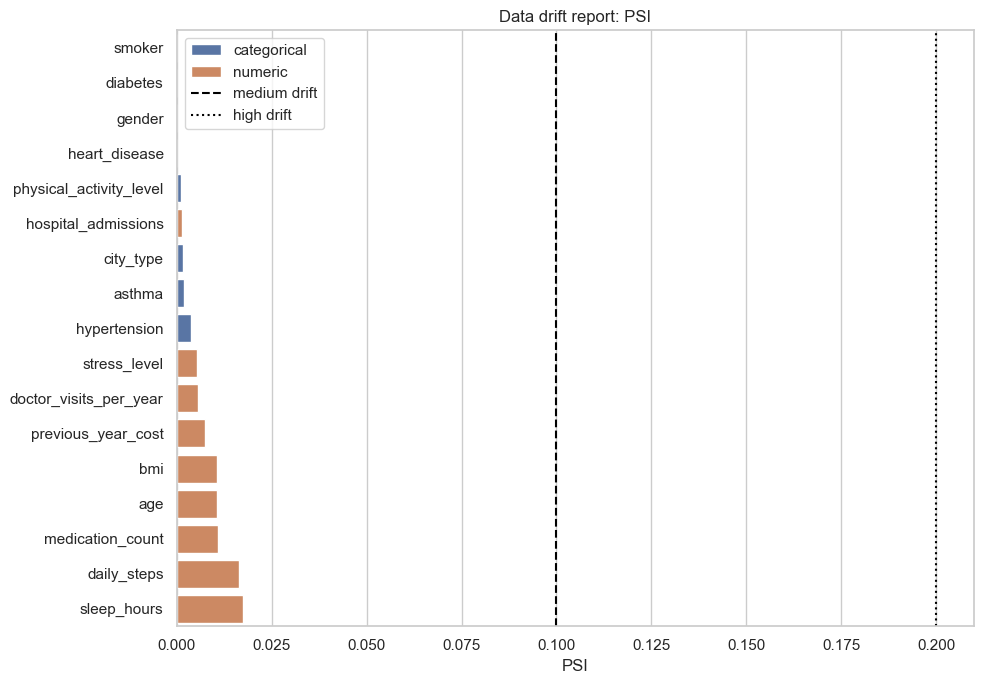

In [8]:
save_drift_plot(
    drift_report=drift_report,
    path=DRIFT_PLOT_PATH,
    top_n=30
)

## 9. Краткая сводка по уровням дрейфа

In [9]:
drift_summary = (
    drift_report
    .groupby(["feature_type", "drift_level"], observed=False)
    .size()
    .reset_index(name="n_features")
)

drift_summary

,feature_type,drift_level,n_features
0,categorical,low,8
1,categorical,medium,0
2,categorical,high,0
3,numeric,low,9
4,numeric,medium,0
5,numeric,high,0


In [10]:
high_drift_features = (
    drift_report
    .query("drift_level == 'high'")
    .sort_values("psi", ascending=False)
)

medium_drift_features = (
    drift_report
    .query("drift_level == 'medium'")
    .sort_values("psi", ascending=False)
)

print("High drift features:")
display(high_drift_features)

print("Medium drift features:")
display(medium_drift_features)

High drift features:


,feature,feature_type,psi,drift_level


Medium drift features:


,feature,feature_type,psi,drift_level


## 10. Интерпретация

В данном ноутбуке train/test split был сделан случайно и стратифицирован по целевой переменной, поэтому сильного дрейфа между train и test обычно ожидать не нужно.

Если некоторые признаки показывают высокий PSI, это означает, что их распределение заметно отличается между train и test. В production такой сигнал может означать изменение входящего потока данных: например, другой возрастной состав пациентов, изменение доли курящих пациентов, другой профиль медицинской нагрузки или смещение по региону.